# India Unemployment Analysis During COVID-19

## Project Overview

This notebook analyzes unemployment trends in India before and after the COVID-19 lockdown period. The analysis covers:

* National unemployment trend over time
* Rural vs urban unemployment comparison
* Pre-lockdown vs post-lockdown unemployment distribution
* Regional unemployment peaks
* Relationship between labour participation and unemployment
* Employment vs unemployment correlation

## 1. Import Libraries

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
unemployment_df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Desktop\\india-unemployment-analysis\\data\\Unemployment in India.csv")
rate_df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Desktop\\india-unemployment-analysis\\data\\Unemployment_Rate_upto_11_2020.csv")

## 3. Preview Dataset

In [3]:
print('=== Unemployment in India Dataset ===')
display(unemployment_df.head())

print('=== Unemployment Rate upto 11/2020 Dataset ===')
display(rate_df.head())

=== Unemployment in India Dataset ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


=== Unemployment Rate upto 11/2020 Dataset ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## 4. Data Cleaning

In [4]:
# Remove extra spaces from column names
unemployment_df.columns = [col.strip() for col in unemployment_df.columns]
rate_df.columns = [col.strip() for col in rate_df.columns]

# Remove rows with missing regions
unemployment_df = unemployment_df.dropna(subset=['Region'])
rate_df = rate_df.dropna(subset=['Region'])

# Convert Date column into datetime format
unemployment_df['Date'] = pd.to_datetime(
    unemployment_df['Date'].astype(str).str.strip(),
    dayfirst=True,
    errors='coerce'
)

rate_df['Date'] = pd.to_datetime(
    rate_df['Date'].astype(str).str.strip(),
    dayfirst=True,
    errors='coerce'
)

## 5. Basic Dataset Information

In [5]:
print('Unemployment Dataset Shape:', unemployment_df.shape)
print('Rate Dataset Shape:', rate_df.shape)

print('\nDate Range (Dataset 1):', unemployment_df['Date'].min(), 'to', unemployment_df['Date'].max())
print('Date Range (Dataset 2):', rate_df['Date'].min(), 'to', rate_df['Date'].max())

print('\nUnique Regions in Dataset 1:', unemployment_df['Region'].nunique())
print('Unique Regions in Dataset 2:', rate_df['Region'].nunique())

print('\nArea Categories:', unemployment_df['Area'].unique())

print('\nMissing Values in Dataset 1:')
print(unemployment_df.isnull().sum())

print('\nMissing Values in Dataset 2:')
print(rate_df.isnull().sum())

Unemployment Dataset Shape: (740, 7)
Rate Dataset Shape: (267, 9)

Date Range (Dataset 1): 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Date Range (Dataset 2): 2020-01-31 00:00:00 to 2020-10-31 00:00:00

Unique Regions in Dataset 1: 28
Unique Regions in Dataset 2: 27

Area Categories: ['Rural' 'Urban']

Missing Values in Dataset 1:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Missing Values in Dataset 2:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                

## 6. Styling and Theme Configuration

In [6]:
# Theme colors
BG = '#0D1117'
CARD = '#161B22'
BORDER = '#30363D'
TXT = '#E6EDF3'
TXT_DIM = '#8B949E'

ACCENT1 = '#58A6FF'
ACCENT2 = '#F78166'
ACCENT3 = '#3FB950'
ACCENT4 = '#D2A8FF'
ACCENT5 = '#FFA657'

RURAL_C = '#3FB950'
URBAN_C = '#58A6FF'
LOCKDOWN_C = '#F78166'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': CARD,
    'axes.edgecolor': BORDER,
    'axes.labelcolor': TXT,
    'xtick.color': TXT_DIM,
    'ytick.color': TXT_DIM,
    'text.color': TXT,
    'grid.color': BORDER,
    'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold'
})

## 7. Feature Engineering

In [7]:
UR = 'Estimated Unemployment Rate (%)'
EMP = 'Estimated Employed'
LPR = 'Estimated Labour Participation Rate (%)'

# National unemployment trend
national_trend = rate_df.groupby('Date')[UR].mean().reset_index().sort_values('Date')

# Rural vs Urban unemployment
rural_urban_df = unemployment_df[
    unemployment_df['Area'].isin(['Rural', 'Urban'])
].copy()

rural_urban_trend = rural_urban_df.groupby(['Date', 'Area'])[UR].mean().unstack('Area')

# Lockdown split
lockdown_date = pd.Timestamp('2020-03-25')
pre_lockdown = rate_df[rate_df['Date'] < lockdown_date]
post_lockdown = rate_df[rate_df['Date'] >= lockdown_date]

# Regional peak unemployment
region_peak = rate_df.groupby('Region')[UR].max().sort_values(ascending=False)

## 8. Create Dashboard Visualizations

In [8]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
fig.subplots_adjust(hspace=0.42, wspace=0.32)

gs = gridspec.GridSpec(4, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :2])
ax3 = fig.add_subplot(gs[1, 2])
ax4 = fig.add_subplot(gs[2, :])
ax5 = fig.add_subplot(gs[3, 0])
ax6 = fig.add_subplot(gs[3, 1])
ax7 = fig.add_subplot(gs[3, 2])

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    ax.set_facecolor(CARD)
    ax.tick_params(colors=TXT_DIM, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

### National Unemployment Trend

In [9]:
ax1.fill_between(national_trend['Date'], national_trend[UR], alpha=0.18, color=ACCENT1)
ax1.plot(national_trend['Date'], national_trend[UR], color=ACCENT1, linewidth=2)
ax1.axvline(lockdown_date, color=LOCKDOWN_C, linestyle='--', linewidth=1.8)

ax1.set_title('National Unemployment Rate Over Time (2020)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.grid(True, axis='y')

### Rural vs Urban Trend

In [10]:
if 'Rural' in rural_urban_trend.columns:
    ax2.plot(rural_urban_trend.index, rural_urban_trend['Rural'],
             color=RURAL_C, linewidth=2, label='Rural')

if 'Urban' in rural_urban_trend.columns:
    ax2.plot(rural_urban_trend.index, rural_urban_trend['Urban'],
             color=URBAN_C, linewidth=2, label='Urban')

ax2.axvline(lockdown_date, color=LOCKDOWN_C, linestyle='--', linewidth=1.5)
ax2.set_title('Rural vs Urban Unemployment Trend')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.legend()
ax2.grid(True, axis='y')

### Pre vs Post Lockdown Distribution

In [11]:
box_data = [
    pre_lockdown[UR].dropna(),
    post_lockdown[UR].dropna()
]

ax3.boxplot(box_data, patch_artist=True)
ax3.set_xticklabels(['Pre-Lockdown', 'Post-Lockdown'])
ax3.set_title('Pre vs Post Lockdown Unemployment Distribution')

Text(0.5, 1.0, 'Pre vs Post Lockdown Unemployment Distribution')

### Labour Participation vs Unemployment

In [12]:
valid_data = rate_df[[LPR, UR]].dropna()

m, b = np.polyfit(valid_data[LPR], valid_data[UR], 1)

x_line = np.linspace(valid_data[LPR].min(), valid_data[LPR].max(), 100)
y_line = m * x_line + b

ax7.scatter(valid_data[LPR], valid_data[UR], alpha=0.6, color=ACCENT4)
ax7.plot(x_line, y_line, linestyle='--', color=ACCENT2)

ax7.set_title('Labour Participation Rate vs Unemployment Rate')
ax7.set_xlabel('Labour Participation Rate (%)')
ax7.set_ylabel('Unemployment Rate (%)')

Text(1203.730463980464, 0.5, 'Unemployment Rate (%)')

### Final Dashboard Display

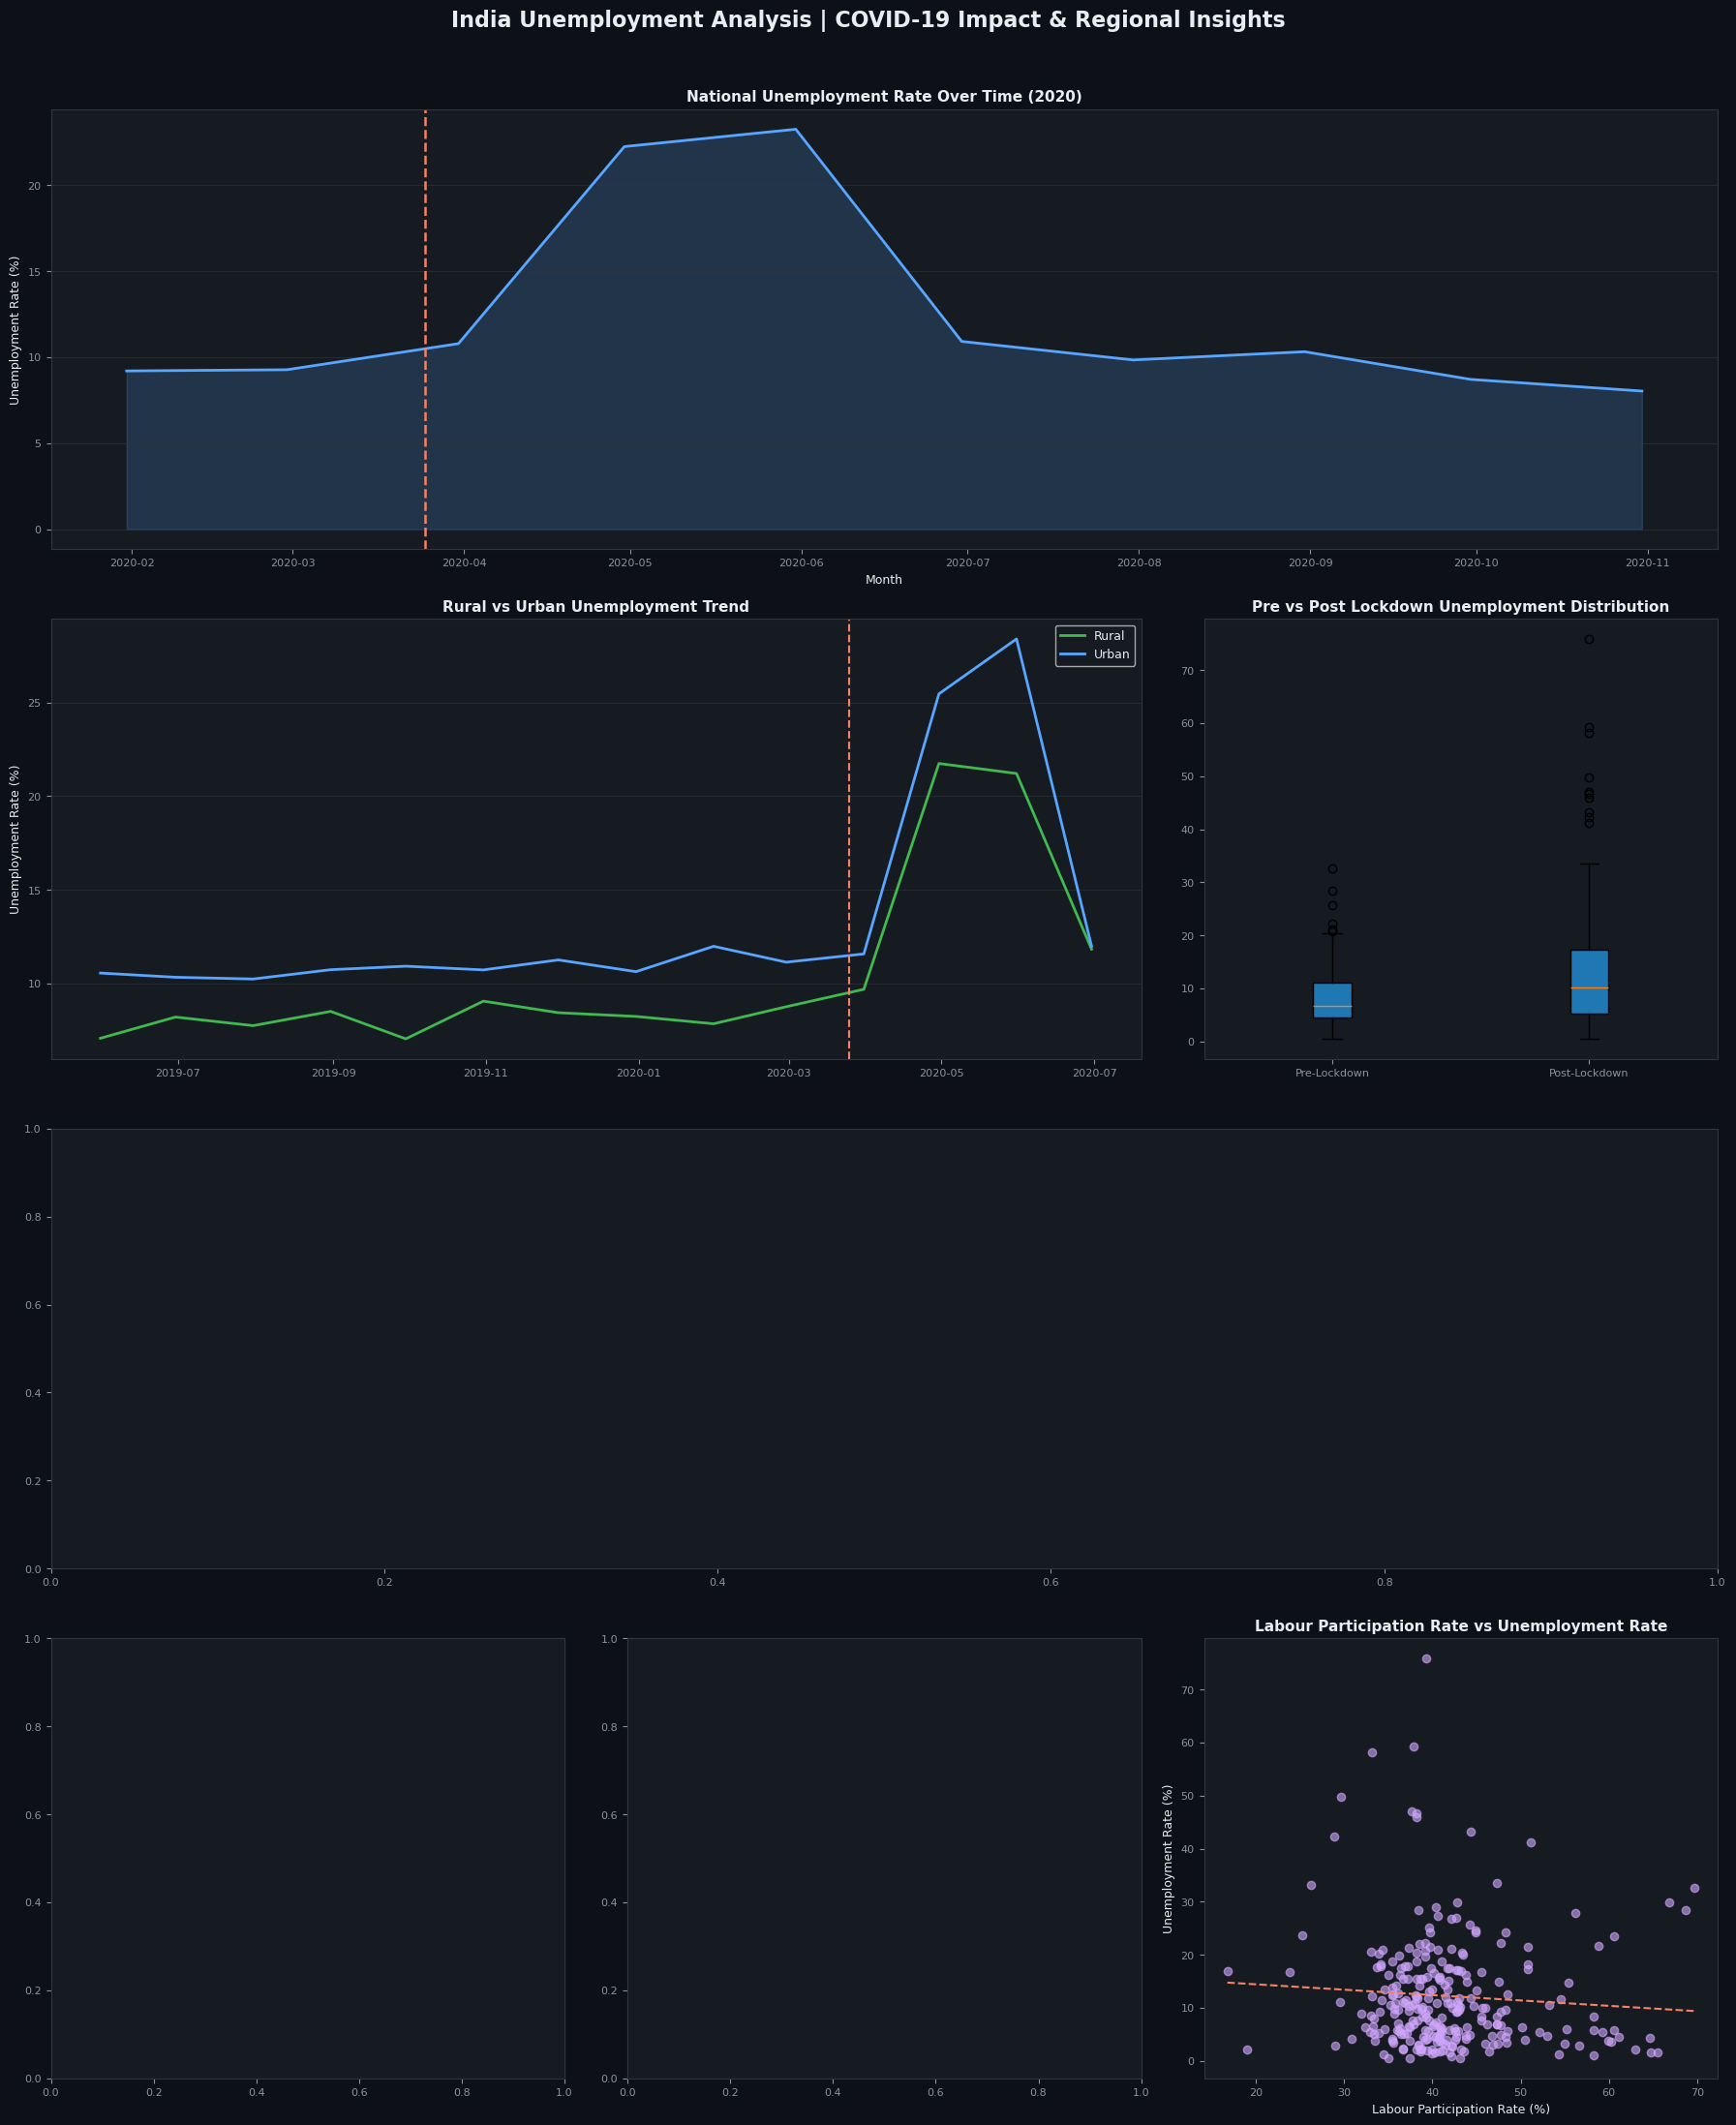

In [13]:
fig.suptitle(
    'India Unemployment Analysis | COVID-19 Impact & Regional Insights',
    fontsize=16,
    fontweight='bold',
    color=TXT,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 9. Key Insights

In [14]:
print(f'Pre-lockdown mean unemployment rate: {pre_lockdown[UR].mean():.2f}%')
print(f'Post-lockdown mean unemployment rate: {post_lockdown[UR].mean():.2f}%')
print(f'Absolute increase after lockdown: {(post_lockdown[UR].mean() - pre_lockdown[UR].mean()):.2f}%')
print(f'Peak national unemployment rate: {national_trend[UR].max():.2f}%')
print(f'Top region by unemployment: {region_peak.index[0]} ({region_peak.iloc[0]:.2f}%)')
print(f'LPR vs UR trend slope: {m:.3f}')

Pre-lockdown mean unemployment rate: 9.23%
Post-lockdown mean unemployment rate: 12.96%
Absolute increase after lockdown: 3.73%
Peak national unemployment rate: 23.24%
Top region by unemployment: Puducherry (75.85%)
LPR vs UR trend slope: -0.101


### Regional Peak Unemployment

In [15]:
top_regions = region_peak.head(15)

ax4.barh(top_regions.index, top_regions.values, color=ACCENT2)
ax4.set_title('Top 15 Regions by Peak Unemployment Rate')
ax4.set_xlabel('Unemployment Rate (%)')



ax6.scatter(
    rate_df[EMP] / 1e6,
    rate_df[UR],
    alpha=0.7
)

### Employment vs Unemployment

In [16]:
ax6.set_title('Employment vs Unemployment Rate')
ax6.set_xlabel('Estimated Employed (Millions)')
ax6.set_ylabel('Unemployment Rate (%)')

Text(615.0000000000001, 0.5, 'Unemployment Rate (%)')

## 10. Conclusion

This analysis clearly shows that unemployment in India sharply increased after the COVID-19 lockdown. Urban areas experienced stronger unemployment spikes compared to rural areas, and some states were hit much harder than others.

The dashboard also highlights the relationship between labour participation and unemployment, which can be useful for further economic policy analysis.
